# Scaling with distractors — baseline (2 hidden units, 2-class classification, non-stationary)

First in a planned series. Here we establish the baseline:
- 1-hidden-layer MLP with **2 hidden units**, leaky_relu activation, lecun_uniform init, **2 output logits + softmax**.
- Synthetic 2D **classification** task. For each class `k ∈ {0, 1}` we draw `(a_k, b_k, c_k) ~ Uniform[-1, 1]` and normalize so each row sums to 1. The per-class target logit is
  `t_k = a_k * leaky_relu(x1) + b_k * leaky_relu(-x2) + c_k * leaky_relu(x2 - x1) + N(0, var=0.1)`.
  The **label** is `argmax_k t_k` (so the additive noise on the logits induces label noise).
- **Non-stationary:** the coefficient matrix is **redrawn every `RESAMPLE_EVERY=500` steps**, so the target function jumps to a fresh draw at each block boundary.
- `x1, x2 ~ Uniform[-1, 1]` independently, fresh each step.
- SGD, batch size 1, softmax cross-entropy loss, 20k steps. LR swept over powers of 2 (5 seeds each), final run uses 30 seeds at the best LR.
- Built with `jax.lax.scan` over the training body + `jax.vmap` over seeds.

Follow-ups: scale the number of hidden units, then add distractor inputs.

In [50]:
import jax
import jax.numpy as jnp
import equinox as eqx
import equinox.nn as nn
import optax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd.jax_core.optimizers.optimizer import EqxOptimizer
from phd.jax_core.models import lecun_uniform
from phd.research_utils.analysis.plotting import plot_param_sensitivity, plot_learning_curves

In [51]:
# Hyperparameters
N_STEPS = 20_000
IN_DIM = 2
HIDDEN_DIM = 2
N_CLASSES = 2
LOGIT_NOISE_VAR = 0.1  # additive noise on each target logit (creates label noise after argmax)
RESAMPLE_EVERY = 500   # resample target coefficients (a, b, c) every this many steps (non-stationary target)
LRS = [2.0 ** p for p in range(-12, -1)]  # 11 values: 2^-12, ..., 2^-2
N_SEEDS_SWEEP = 5
N_SEEDS_FINAL = 30
LAST_FRAC = 0.20  # average loss/accuracy over last 20% of steps for sensitivity

In [52]:
def target_logits(x1, x2, coefs):
    """Per-class target logits given coefficients.

    coefs: array of shape (N_CLASSES, 3) — coefs[k] = (a_k, b_k, c_k).
    Returns an array of logits with shape (N_CLASSES,).
    Broadcasts over leading axes of x1, x2 (e.g. for a grid) — result is
    (N_CLASSES, *x1.shape).
    """
    a = coefs[:, 0]
    b = coefs[:, 1]
    c = coefs[:, 2]
    # Reshape coef vectors so they broadcast against any-shape (x1, x2).
    extra = (1,) * jnp.ndim(x1)
    a = a.reshape((N_CLASSES,) + extra)
    b = b.reshape((N_CLASSES,) + extra)
    c = c.reshape((N_CLASSES,) + extra)
    return (
        a * jax.nn.leaky_relu(x1)
        + b * jax.nn.leaky_relu(-x2)
        + c * jax.nn.leaky_relu(x2 - x1)
    )


def draw_coefs(key):
    """Draw (N_CLASSES, 3) coefficient matrix, each row normalized to sum to 1."""
    raw = jax.random.uniform(key, (N_CLASSES, 3), minval=-1.0, maxval=1.0)
    return raw / raw.sum(axis=1, keepdims=True)

## Figure 1: target decision regions

Decision regions (`argmax_k t_k`) for a representative draw of class coefficients (`PRNGKey(0)`). Each seed in the experiment draws its own coefficient matrix the same way, so this is one sample from the target distribution. Computed on the **noiseless** target — at train time we add `N(0, var=0.1)` to each logit before argmax, which produces label noise.

demo coefs (each row sums to 1):
[[ 0.59017056  0.6309238  -0.22109431]
 [ 0.10587132 -0.23615853  1.1302872 ]]


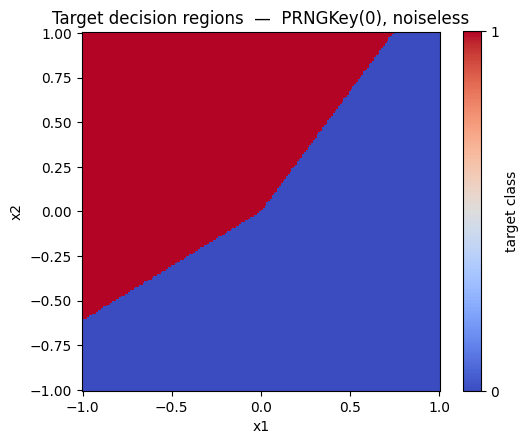

In [53]:
demo_coefs = draw_coefs(jax.random.PRNGKey(0))
print('demo coefs (each row sums to 1):')
print(np.asarray(demo_coefs))

grid = jnp.linspace(-1.0, 1.0, 200)
X1, X2 = jnp.meshgrid(grid, grid, indexing='xy')
logits_grid = target_logits(X1, X2, demo_coefs)  # (N_CLASSES, 200, 200)
labels_grid = np.asarray(jnp.argmax(logits_grid, axis=0))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
mesh = ax.pcolormesh(
    np.asarray(X1), np.asarray(X2), labels_grid,
    shading='auto', cmap='coolwarm', vmin=0, vmax=N_CLASSES - 1,
)
cbar = fig.colorbar(mesh, ax=ax, ticks=list(range(N_CLASSES)), label='target class')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Target decision regions  —  PRNGKey(0), noiseless')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Model and training

Hand-built tiny MLP rather than the heavier `phd.jax_core.models.MLP` so this stays self-contained. Two `nn.Linear` layers, no bias (matching the default in `MLP._create_linear_layer`), weights reinitialized with `lecun_uniform`, leaky_relu activation in between. Output is `N_CLASSES=2` logits — softmax is implicit in the cross-entropy loss.

In [54]:
class TinyMLP(eqx.Module):
    layer1: nn.Linear
    layer2: nn.Linear

    def __init__(self, in_dim, hidden_dim, out_dim, *, key):
        k1, k2 = jax.random.split(key, 2)
        l1 = nn.Linear(in_dim, hidden_dim, use_bias=False, key=k1)
        l2 = nn.Linear(hidden_dim, out_dim, use_bias=False, key=k2)
        l1 = eqx.tree_at(lambda l: l.weight, l1, lecun_uniform(k1, (hidden_dim, in_dim), in_dim=in_dim))
        l2 = eqx.tree_at(lambda l: l.weight, l2, lecun_uniform(k2, (out_dim, hidden_dim), in_dim=hidden_dim))
        self.layer1 = l1
        self.layer2 = l2

    def __call__(self, x):
        h = jax.nn.leaky_relu(self.layer1(x))
        return self.layer2(h)  # (out_dim,) logits

In [55]:
def loss_fn(model, x, label):
    logits = model(x)  # (N_CLASSES,)
    return optax.softmax_cross_entropy_with_integer_labels(logits, label)


def scan_step(carry, step_key):
    model, opt, coefs, step = carry
    kx, knoise, kcoef = jax.random.split(step_key, 3)

    # Non-stationarity: resample target coefficients every RESAMPLE_EVERY steps
    # (skip at step 0 so the initial draw from train_one_seed is honored for the first block).
    should_resample = (step > 0) & (step % RESAMPLE_EVERY == 0)
    coefs = jnp.where(should_resample, draw_coefs(kcoef), coefs)

    x = jax.random.uniform(kx, (2,), minval=-1.0, maxval=1.0)
    clean = target_logits(x[0], x[1], coefs)                       # (N_CLASSES,)
    noise = jax.random.normal(knoise, (N_CLASSES,)) * jnp.sqrt(LOGIT_NOISE_VAR)
    label = jnp.argmax(clean + noise)                              # scalar int

    # Accuracy measured BEFORE the update — the prediction the model would
    # have made on this step's input given its current weights.
    pred = jnp.argmax(model(x))
    accuracy = (pred == label).astype(jnp.float32)

    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, label)
    updates, opt = opt.with_update(grads, model)
    model = eqx.apply_updates(model, updates)
    return (model, opt, coefs, step + 1), (loss, accuracy)


def train_one_seed(seed, lr):
    key = jax.random.PRNGKey(seed)
    k_model, k_coef, k_steps = jax.random.split(key, 3)

    coefs = draw_coefs(k_coef)  # (N_CLASSES, 3), each row sums to 1 — initial block's target

    model = TinyMLP(IN_DIM, HIDDEN_DIM, N_CLASSES, key=k_model)
    # inject_hyperparams threads `lr` through optimizer state (instead of closing
    # over it), which is what makes the optimizer safe to vmap over different LRs.
    optimizer = optax.inject_hyperparams(optax.sgd)(learning_rate=lr)
    opt = EqxOptimizer(optimizer, model)

    step_keys = jax.random.split(k_steps, N_STEPS)
    init_carry = (model, opt, coefs, jnp.int32(0))
    (model, opt, _, _), (losses, accuracies) = jax.lax.scan(
        scan_step, init_carry, step_keys
    )
    return losses, accuracies


# vmap only over seeds (lr is a scalar) — used for the final 30-seed run at the best LR.
train_seeds = eqx.filter_jit(jax.vmap(train_one_seed, in_axes=(0, None)))

# vmap over both LR (outer) and seeds (inner) — used by the LR sweep.
# Output shape per metric: (n_lrs, n_seeds, N_STEPS).
train_grid = eqx.filter_jit(
    jax.vmap(jax.vmap(train_one_seed, in_axes=(0, None)), in_axes=(None, 0))
)

## LR sweep (5 seeds per LR)

In [56]:
sweep_seeds = jnp.arange(N_SEEDS_SWEEP)
lr_arr = jnp.asarray(LRS)
n_tail = int(N_STEPS * LAST_FRAC)

# Single jitted call: (n_lrs, n_seeds, N_STEPS) per metric.
all_losses, all_accs = train_grid(sweep_seeds, lr_arr)
all_losses = np.asarray(all_losses)
all_accs = np.asarray(all_accs)

sweep_rows = []
for lr_idx, lr in enumerate(LRS):
    tail_loss_per_seed = all_losses[lr_idx, :, -n_tail:].mean(axis=1)  # (N_SEEDS_SWEEP,)
    tail_acc_per_seed = all_accs[lr_idx, :, -n_tail:].mean(axis=1)
    for seed_idx, (tl, ta) in enumerate(zip(tail_loss_per_seed, tail_acc_per_seed)):
        sweep_rows.append({
            'run_id': f'lr{lr:.6f}_seed{seed_idx}',
            'lr': lr,
            'step': N_STEPS - 1,
            'loss': float(tl),
            'accuracy': float(ta),
        })
    print(f"lr={lr:.6f}  last-{int(LAST_FRAC*100)}%  CE mean={tail_loss_per_seed.mean():.4f} std={tail_loss_per_seed.std():.4f}  "
          f"|  acc mean={tail_acc_per_seed.mean():.3f} std={tail_acc_per_seed.std():.3f}")

sweep_df = pd.DataFrame(sweep_rows)

best_lr = sweep_df.groupby('lr')['loss'].mean().idxmin()
best_lr_by_acc = sweep_df.groupby('lr')['accuracy'].mean().idxmax()
print(f"\nBest LR by CE loss: {best_lr}  (2^{int(np.log2(best_lr))})")
print(f"Best LR by accuracy: {best_lr_by_acc}  (2^{int(np.log2(best_lr_by_acc))})")

lr=0.000244  last-20%  CE mean=0.7020 std=0.0081  |  acc mean=0.483 std=0.052
lr=0.000488  last-20%  CE mean=0.6933 std=0.0069  |  acc mean=0.521 std=0.071
lr=0.000977  last-20%  CE mean=0.6880 std=0.0081  |  acc mean=0.550 std=0.059
lr=0.001953  last-20%  CE mean=0.6844 std=0.0121  |  acc mean=0.544 std=0.067
lr=0.003906  last-20%  CE mean=0.6777 std=0.0176  |  acc mean=0.566 std=0.061
lr=0.007812  last-20%  CE mean=0.6667 std=0.0229  |  acc mean=0.606 std=0.057
lr=0.015625  last-20%  CE mean=0.6435 std=0.0147  |  acc mean=0.654 std=0.029
lr=0.031250  last-20%  CE mean=0.5744 std=0.0139  |  acc mean=0.704 std=0.009
lr=0.062500  last-20%  CE mean=0.4863 std=0.0232  |  acc mean=0.764 std=0.024
lr=0.125000  last-20%  CE mean=0.4532 std=0.0431  |  acc mean=0.790 std=0.028
lr=0.250000  last-20%  CE mean=0.4574 std=0.0636  |  acc mean=0.803 std=0.031

Best LR by CE loss: 0.125  (2^-3)
Best LR by accuracy: 0.25  (2^-2)


## Figure 2a: LR sensitivity — CE loss (last-20% mean)

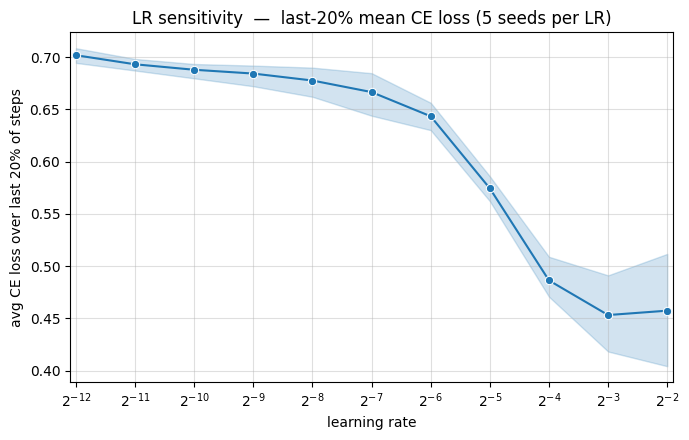

In [57]:
plt.figure(figsize=(7, 4.5))
plot_param_sensitivity(
    run_df=sweep_df,
    config_df=None,
    x_col='lr',
    title='LR sensitivity  —  last-20% mean CE loss (5 seeds per LR)',
    x_label='learning rate',
    y_label='avg CE loss over last 20% of steps',
    metric_col='loss',
    metric_type='last',
    pow_2_x_axis=True,
    show_ci=True,
)
plt.tight_layout()
plt.show()

## Figure 2b: LR sensitivity — accuracy (last-20% mean)

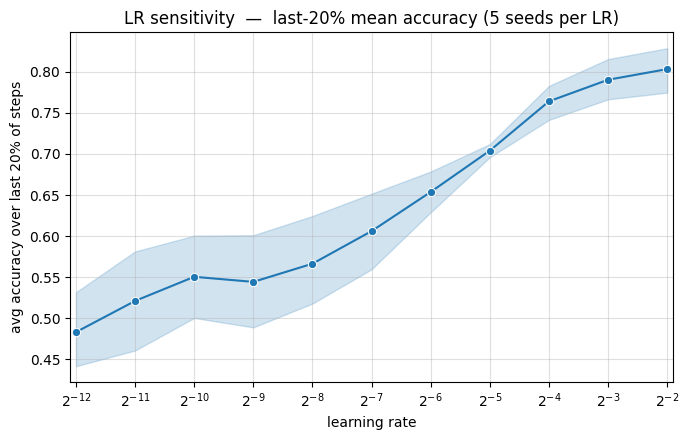

In [58]:
plt.figure(figsize=(7, 4.5))
plot_param_sensitivity(
    run_df=sweep_df,
    config_df=None,
    x_col='lr',
    title='LR sensitivity  —  last-20% mean accuracy (5 seeds per LR)',
    x_label='learning rate',
    y_label='avg accuracy over last 20% of steps',
    metric_col='accuracy',
    metric_type='last',
    pow_2_x_axis=True,
    show_ci=True,
)
plt.tight_layout()
plt.show()

## Final run: 30 seeds at the best LR

In [59]:
final_seeds = jnp.arange(N_SEEDS_FINAL) + 10_000  # offset so we don't reuse sweep seeds
final_losses, final_accs = train_seeds(final_seeds, best_lr)  # each (30, N_STEPS)
final_losses = np.asarray(final_losses)
final_accs = np.asarray(final_accs)

# Subsample every 10th step to keep the DataFrame small; plot_learning_curves rebins.
step_stride = 10
sub_steps = np.arange(0, N_STEPS, step_stride)
sub_losses = final_losses[:, ::step_stride]
sub_accs = final_accs[:, ::step_stride]

final_df = pd.DataFrame({
    'run_id': np.repeat(np.arange(N_SEEDS_FINAL), len(sub_steps)),
    'step': np.tile(sub_steps, N_SEEDS_FINAL),
    'loss': sub_losses.reshape(-1),
    'accuracy': sub_accs.reshape(-1),
})

n_tail_final = int(N_STEPS * LAST_FRAC)
tail_ce = final_losses[:, -n_tail_final:].mean()
tail_acc = final_accs[:, -n_tail_final:].mean()
print(f"Final-run last-{int(LAST_FRAC*100)}% (30 seeds, lr={best_lr}):")
print(f"  mean CE loss: {tail_ce:.4f}   (uniform-predictor ref: ln(2) = {np.log(2):.4f})")
print(f"  mean accuracy: {tail_acc:.3f}  (chance: 0.500)")

Final-run last-20% (30 seeds, lr=0.125):
  mean CE loss: 0.4718   (uniform-predictor ref: ln(2) = 0.6931)
  mean accuracy: 0.782  (chance: 0.500)


## Figure 3a: learning curve — CE loss (30 seeds at best LR)

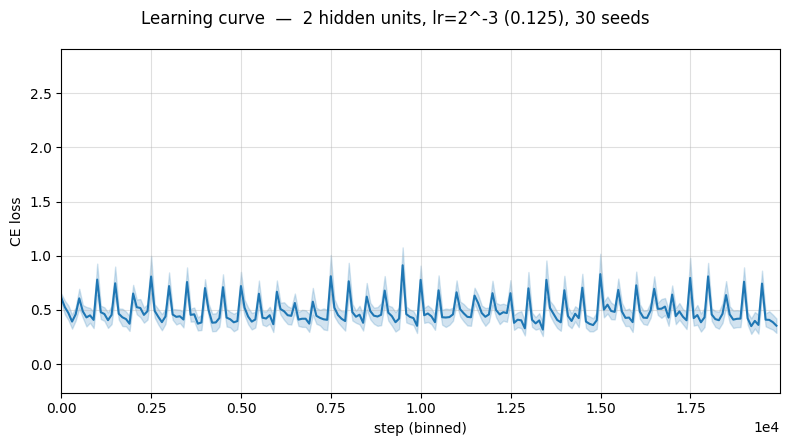

In [60]:
plot_learning_curves(
    run_df=final_df,
    config_df=None,
    x_col='step',
    y_col='loss',
    y_label='CE loss',
    # show_individual_lines=True,
    line_alpha=0.15,
    n_bins=200,
    figsize=(8, 4.5),
    same_y_axis=True,
    show_ci=True,
)
plt.suptitle(f'Learning curve  —  2 hidden units, lr=2^{int(np.log2(best_lr))} ({best_lr}), 30 seeds')
plt.tight_layout()
plt.show()

## Figure 3b: learning curve — accuracy (30 seeds at best LR)

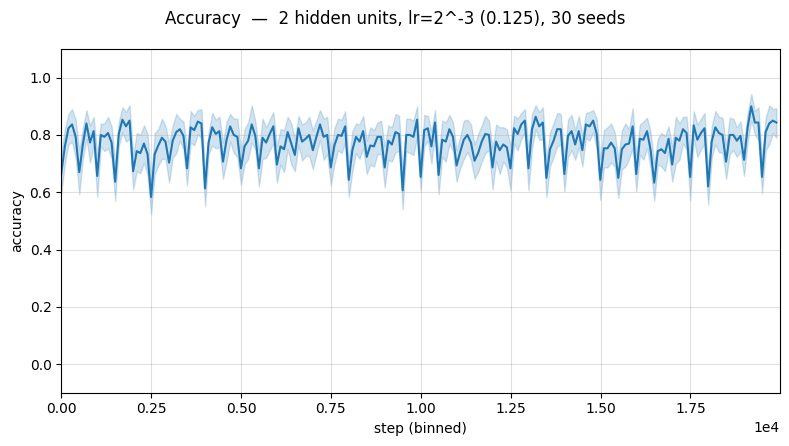

In [61]:
plot_learning_curves(
    run_df=final_df,
    config_df=None,
    x_col='step',
    y_col='accuracy',
    y_label='accuracy',
    # show_individual_lines=True,
    line_alpha=0.15,
    n_bins=200,
    figsize=(8, 4.5),
    same_y_axis=True,
    show_ci=True,
)
plt.suptitle(f'Accuracy  —  2 hidden units, lr=2^{int(np.log2(best_lr))} ({best_lr}), 30 seeds')
plt.tight_layout()
plt.show()

## Notes

- Loss is softmax cross-entropy on the argmax label. Uniform-over-classes ref: `ln(2) ≈ 0.693`. A perfect Bayes-optimal predictor would still pay positive CE because of the logit noise (`var=0.1`).
- Target is **non-stationary**: coefficients resample every `RESAMPLE_EVERY=500` steps, so we expect periodic spikes in the learning curve right after each boundary as the model re-adapts. The last-20% average smooths over the last `N_STEPS * 0.20 / RESAMPLE_EVERY = 8` blocks at default settings.
- Next: vary `HIDDEN_DIM` and re-run the same sweep, then add distractor inputs.